In [ ]:
# imports & paths ---
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project paths (adjust if you placed the project elsewhere)
PROJ = Path.cwd().parents[0]  # notebooks/ -> project root
DATA_RAW = PROJ / "data" / "raw"
REPORTS = PROJ / "reports"
FIGS = REPORTS / "figures"
REPORTS.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

CSV_PATH = DATA_RAW / "Preprocessed_Depression_Dataset.csv"  # <-- your uploaded file copied here
print("Using:", CSV_PATH)

Using: d:\Git\DepressionLevel\DepressionModelProject\data\raw\Preprocessed_Depression_Dataset.csv


In [ ]:
#  Load the dataset ---
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
df.head(10)

Shape: (501, 14)


,Timestamp,What is Your Age group?,What is Your Gender,"1. Have You Been Feeling Sad Most of The Time During The Day, Especially Over The Last Two Weeks ?",2. Do You Feel Unhappy Even When You Do Your Favorite Activities ?,"3. Do You Feel Tired All The Time , Do You Find It Difficulty to Complete Day Today Usual Activity ?",4. Do you often catch yourself getting distracted while working on something important?,"5. Do you often feel that you're not as capable as your friends, even when you try your best?",6. Do you often feel guilty about things that aren't your fault or feel worthless?,7. Do you feel as if things won’t get better no matter what you do?,"8. Lately, have you felt so overwhelmed or hopeless that you thought about giving up on everything and even Life?","9. Have you been having trouble falling asleep, waking early, or sleeping too much?",10. Have you lost your appetite or found that you’re eating much less than usual?,Depression Level
0,2025-07-05 16:18:40.390,18-25,Female,Yes,Yes,Yes,Yes,No,Yes,No,Yes,Yes,Yes,Severe Depression
1,2025-07-08 13:24:43.715,36-45,Female,No,No,No,No,Yes,Yes,Yes,Yes,No,No,No Depression
2,2025-07-08 13:27:28.382,26-35,Male,No,Yes,Yes,No,No,No,No,Yes,Yes,No,No Depression
3,2025-07-08 14:57:28.901,36-45,Male,Yes,No,Yes,Yes,Yes,No,No,No,No,No,No Depression
4,2025-07-08 15:01:20.683,26-35,Female,Yes,Yes,Yes,Yes,No,No,Yes,No,Yes,No,Moderate Depression
5,2025-07-08 15:02:21.622,45-55,Female,Yes,No,Yes,Yes,Yes,No,No,No,No,No,No Depression
6,2025-07-08 15:04:05.495,26-35,Male,Yes,Yes,Yes,Yes,Yes,No,No,No,Yes,No,Moderate Depression
7,2025-07-08 15:05:14.493,36-45,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,No,Yes,Yes,Severe Depression
8,2025-07-08 15:07:25.368,26-35,Female,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Severe Depression
9,2025-07-08 15:08:26.977,36-45,Male,No,No,No,No,No,No,No,No,No,No,No Depression


In [3]:
# --- Build a simple audit table ---
def is_numeric(s):
    return pd.api.types.is_numeric_dtype(s)

rows = []
n_rows = len(df)

for col in df.columns:
    s = df[col]
    non_null = s.notna().sum()
    miss = n_rows - non_null
    miss_pct = (miss / n_rows * 100.0) if n_rows else 0.0
    nunique = s.nunique(dropna=True)
    stats = {
        "column": col,
        "dtype": str(s.dtype),
        "non_null": int(non_null),
        "missing": int(miss),
        "missing_pct": round(miss_pct, 3),
        "n_unique": int(nunique),
        "is_numeric": bool(is_numeric(s)),
    }
    if is_numeric(s):
        stats.update({
            "min": float(s.min()) if pd.notna(s.min()) else None,
            "max": float(s.max()) if pd.notna(s.max()) else None,
            "mean": float(s.mean()) if pd.notna(s.mean()) else None,
            "std": float(s.std()) if pd.notna(s.std()) else None,
        })
    rows.append(stats)

audit_df = pd.DataFrame(rows).sort_values(["is_numeric","column"], ascending=[False, True])
audit_df.to_csv(REPORTS / "eda_overview.csv", index=False)
print("Saved:", REPORTS / "eda_overview.csv")
audit_df

Saved: d:\Git\DepressionLevel\DepressionModelProject\reports\eda_overview.csv


,column,dtype,non_null,missing,missing_pct,n_unique,is_numeric
3,1. Have You Been Feeling Sad Most of The Time ...,object,501,0,0.0,2,False
12,10. Have you lost your appetite or found that ...,object,501,0,0.0,2,False
4,2. Do You Feel Unhappy Even When You Do Your F...,object,501,0,0.0,2,False
5,"3. Do You Feel Tired All The Time , Do You Fin...",object,501,0,0.0,2,False
6,4. Do you often catch yourself getting distrac...,object,501,0,0.0,2,False
7,5. Do you often feel that you're not as capabl...,object,501,0,0.0,2,False
8,6. Do you often feel guilty about things that ...,object,501,0,0.0,2,False
9,7. Do you feel as if things won’t get better n...,object,501,0,0.0,2,False
10,"8. Lately, have you felt so overwhelmed or hop...",object,501,0,0.0,2,False
11,9. Have you been having trouble falling asleep...,object,501,0,0.0,2,False


In [4]:
# --- Duplicates check ---
dup_count = int(df.duplicated().sum())
print(f"Duplicate rows: {dup_count}")

Duplicate rows: 0


Suggested target candidates (heuristic): ['Depression Level', 'What is Your Age group?', 'What is Your Gender', '1. Have You Been Feeling Sad Most of The Time During The Day, Especially Over The Last Two Weeks ?', '2. Do You Feel Unhappy Even When You Do Your Favorite Activities ?', '3. Do You Feel Tired All The Time , Do You Find It Difficulty to Complete Day Today Usual Activity ?', '4. Do you often catch yourself getting distracted while working on something important?', "5. Do you often feel that you're not as capable as your friends, even when you try your best?", "6. Do you often feel guilty about things that aren't your fault or feel worthless?", '7. Do you feel as if things won’t get better no matter what you do?', '8. Lately, have you felt so overwhelmed or hopeless that you thought about giving up on everything and even Life?', '9. Have you been having trouble falling asleep, waking early, or sleeping too much?', '10. Have you lost your appetite or found that you’re eating mu

Depression Level
No Depression          383
Severe Depression       52
Mild Depression         47
Moderate Depression     19
Name: count, dtype: int64

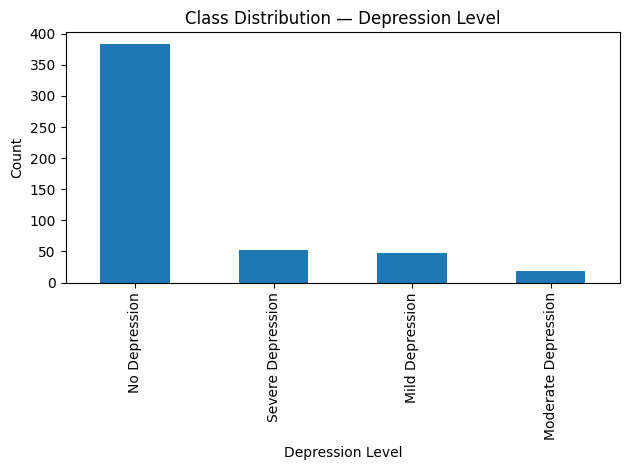

Saved figure: d:\Git\DepressionLevel\DepressionModelProject\reports\figures\class_distribution_Depression_Level.png


In [5]:
# --- Suggest target candidates & show distribution if 'Depression Level' exists ---
name_hints = ("depress", "label", "target", "class", "severity")
candidates_by_name = [c for c in df.columns if any(k in c.lower() for k in name_hints)]

# Low-cardinality candidates (<= 10 unique values), excluding obvious IDs
low_card = []
for c in df.columns:
    nun = df[c].nunique(dropna=True)
    if 2 <= nun <= 10 and not any(k in c.lower() for k in ("id","uuid","email","name","phone")):
        low_card.append(c)

suggested = list(dict.fromkeys(candidates_by_name + low_card))
print("Suggested target candidates (heuristic):", suggested)

target_col = None
for c in suggested:
    if c.lower().strip() in ("depression level", "depression_level", "label", "target"):
        target_col = c
        break

# Fallback: if a column is literally named 'Depression Level'
if target_col is None and "Depression Level" in df.columns:
    target_col = "Depression Level"

print("Chosen target (if found):", target_col)

if target_col:
    vc = df[target_col].astype(str).value_counts(dropna=False)
    display(vc)
    # Plot (saved to figures)
    plt.figure()
    vc.plot(kind="bar", title=f"Class Distribution — {target_col}")
    plt.xlabel(target_col)
    plt.ylabel("Count")
    plt.tight_layout()
    fig_path = FIGS / f"class_distribution_{target_col.replace(' ', '_')}.png"
    plt.savefig(fig_path)
    plt.show()
    print("Saved figure:", fig_path)
else:
    print("No obvious target found. Pick the most appropriate label column for depression level.")